<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter3_pytorch_computer_vision/chapter3_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Thị giác máy tính**

Dược xem là việc dạy mát tính cách để có thể nhìn mọi vật. Lấy ví dụ có thể xây dựng một mô hình để phân loại hình ảnh là chó hay mèo (binary classification), hoặc phân loại xem bức ảnh là chó, mèo hay gà (multi-class classification), hoặc việc xác định xem một chiếc xe có thể xuất hiện ở đâu trong một đoạn phim (object detection), hay việc tìm các bức ảnh về chung một sự vật được biểu diễn khác nhau như thế nào ở đâu (panoptic segmentation)

Xem thêm: [Thị giác máy tính](https://en.wikipedia.org/wiki/Computer_vision), [binary classification](https://developers.google.com/machine-learning/glossary#binary-classification), [multi-class classification](https://developers.google.com/machine-learning/glossary#multi-class-classification), [object detection](https://en.wikipedia.org/wiki/Object_detection), [panoptic segmentation](https://arxiv.org/abs/1801.00868)

# **Thị giác máy tính được sử dụng cho**

Sử dụng trong thiết bị di động, camera và các ứng dụng photo sử dụng thị giác máy tính để nhận diện và sắp xếp hình ảnh, Xe hiện đại sử dụng thị giác máy tính đẻ ngăn chặn va chạm các xe khác và đi đúng đường, doanh nghiệp sử dụng thị giác máy tính để địn nghĩa đếm sản phẩm, camera bảo mật sử dụng thị giác máy tính để nhận diện tác nhân nguy hại


## **0. Thư viện thị giác máy tính trong PyTorch**



- `torchvision:` Lưu trữ bộ dữ liệu, kiến trúc của mô hình và biến đổi hình ảnh thường được sử dụng trong thị giác máy tính
- `torchvision.datasets:` Tìm nhiều ví dụ về thị giác máy tính datasets về phân loại hình ảnh, xác định vật thể, gắn cap cho hình ảnh, phân loại video và có thể tạo nhiều dữ liệu custom (https://docs.pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets)
- `torchvision.models:` Chứa kiến trúc mô hình thị giác máy tính và được sử dụng phổ biến và được triển khai
- `torchvision.transforms:` Thực hiện biến đổi dữ liệu chuyển về số/thực hiện tiền xử lý/augmented trước khi sử dụng mô hình các kỹ thuật xử lý ảnh sẽ được gọi trong đây
- `torch.utils.data.Dataset:` Lớp base cho PyTorch
- `torch.utils.data.DataLoader:` Tạo nhãn lặp cho dữ liệu trong Python (chúng với `torch.utils.data.Dataset`)

Xem thêm: [torchvision](https://docs.pytorch.org/vision/stable/index.html), [torchvision.datasets](https://docs.pytorch.org/vision/stable/datasets.html), [torchvision.models](https://docs.pytorch.org/vision/stable/models.html), [torchvision.transforms](https://docs.pytorch.org/vision/stable/transforms.html), [torch.utils.data.Dataset](https://docs.pytorch.org/docs/2.12/data.html#torch.utils.data.Dataset), [torch.utils.data.DataLoader](https://docs.pytorch.org/docs/2.12/data.html#module-torch.utils.data)

> `torch.utils.data.Dataset` và `torch.utils.data.DataLoader` thường không chỉ sử dụng cho thị giác mà còn có thể sử dụng cho nhiều kiểu dữ liệu khác nhau

In [ ]:
# Thực hiện load dữ liệu

# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

## **1. Lấy bộ dữ liệu**

Để làm việc với bài toán thị giác máy tính, ta cần lấy bộ dữ liệu. Trong bài toán này chính là bộ dữ liệu FashionMNIST (Modified National Institute of Standards and Technology) - bộ dữ liệu chứa hàng ngàn mẫu dữ liệu 10 phụ kiện quần áo khác nhau [ original MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database): là bộ dữ liệu chữ viết tay từ (0 - 9) và được sử dụng cho thị giác máy tính

Nhiệm vụ của ta bây giờ là xây dựng mô hình thị giác máy tính mạng nơ-ron thực hiện việc phân loại hình ảnh. Và Pytorch có hàng tá các datasets trong module `torchvision.datasets` bao gồm cả FashionMNIST trong `torchvision.datasets.FashionMNIST()`

Để tải dữ liệu ta thực hiện:
- `root: str` - dữ liệu khi tải sẽ được lưu ở đâu
- `train: Bool` - có muốn chia training hoặc test không
- `download: Bool` - data nên tải không
- `transform: torchvision.transforms` - Bộ biến đổi nào nên sử dụng cho dữ liệu
- `target_transform` - ta có thể biến đổi target (nhãn)

In [ ]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

In [ ]:
# See first training sample
image, label = train_data[0]
image, label

### **Shape của đầu vào và đầu ra của mô hình thị giác máy tính**


Ta có một tensor lớn chứa các giá trị của ảnh cùng với đó là một giá trị duy nhất chính là target hay nhãn của ảnh đó

In [ ]:
# What's the shape of the image?
image.shape

Shape của hifnha rnh là `[1, 28, 28]` điều này cho biết

```
[color_channels = 1, height = 28, width = 28]
```

Có `color_channels = 1` tức là hình có một màu duy nhát (xám)


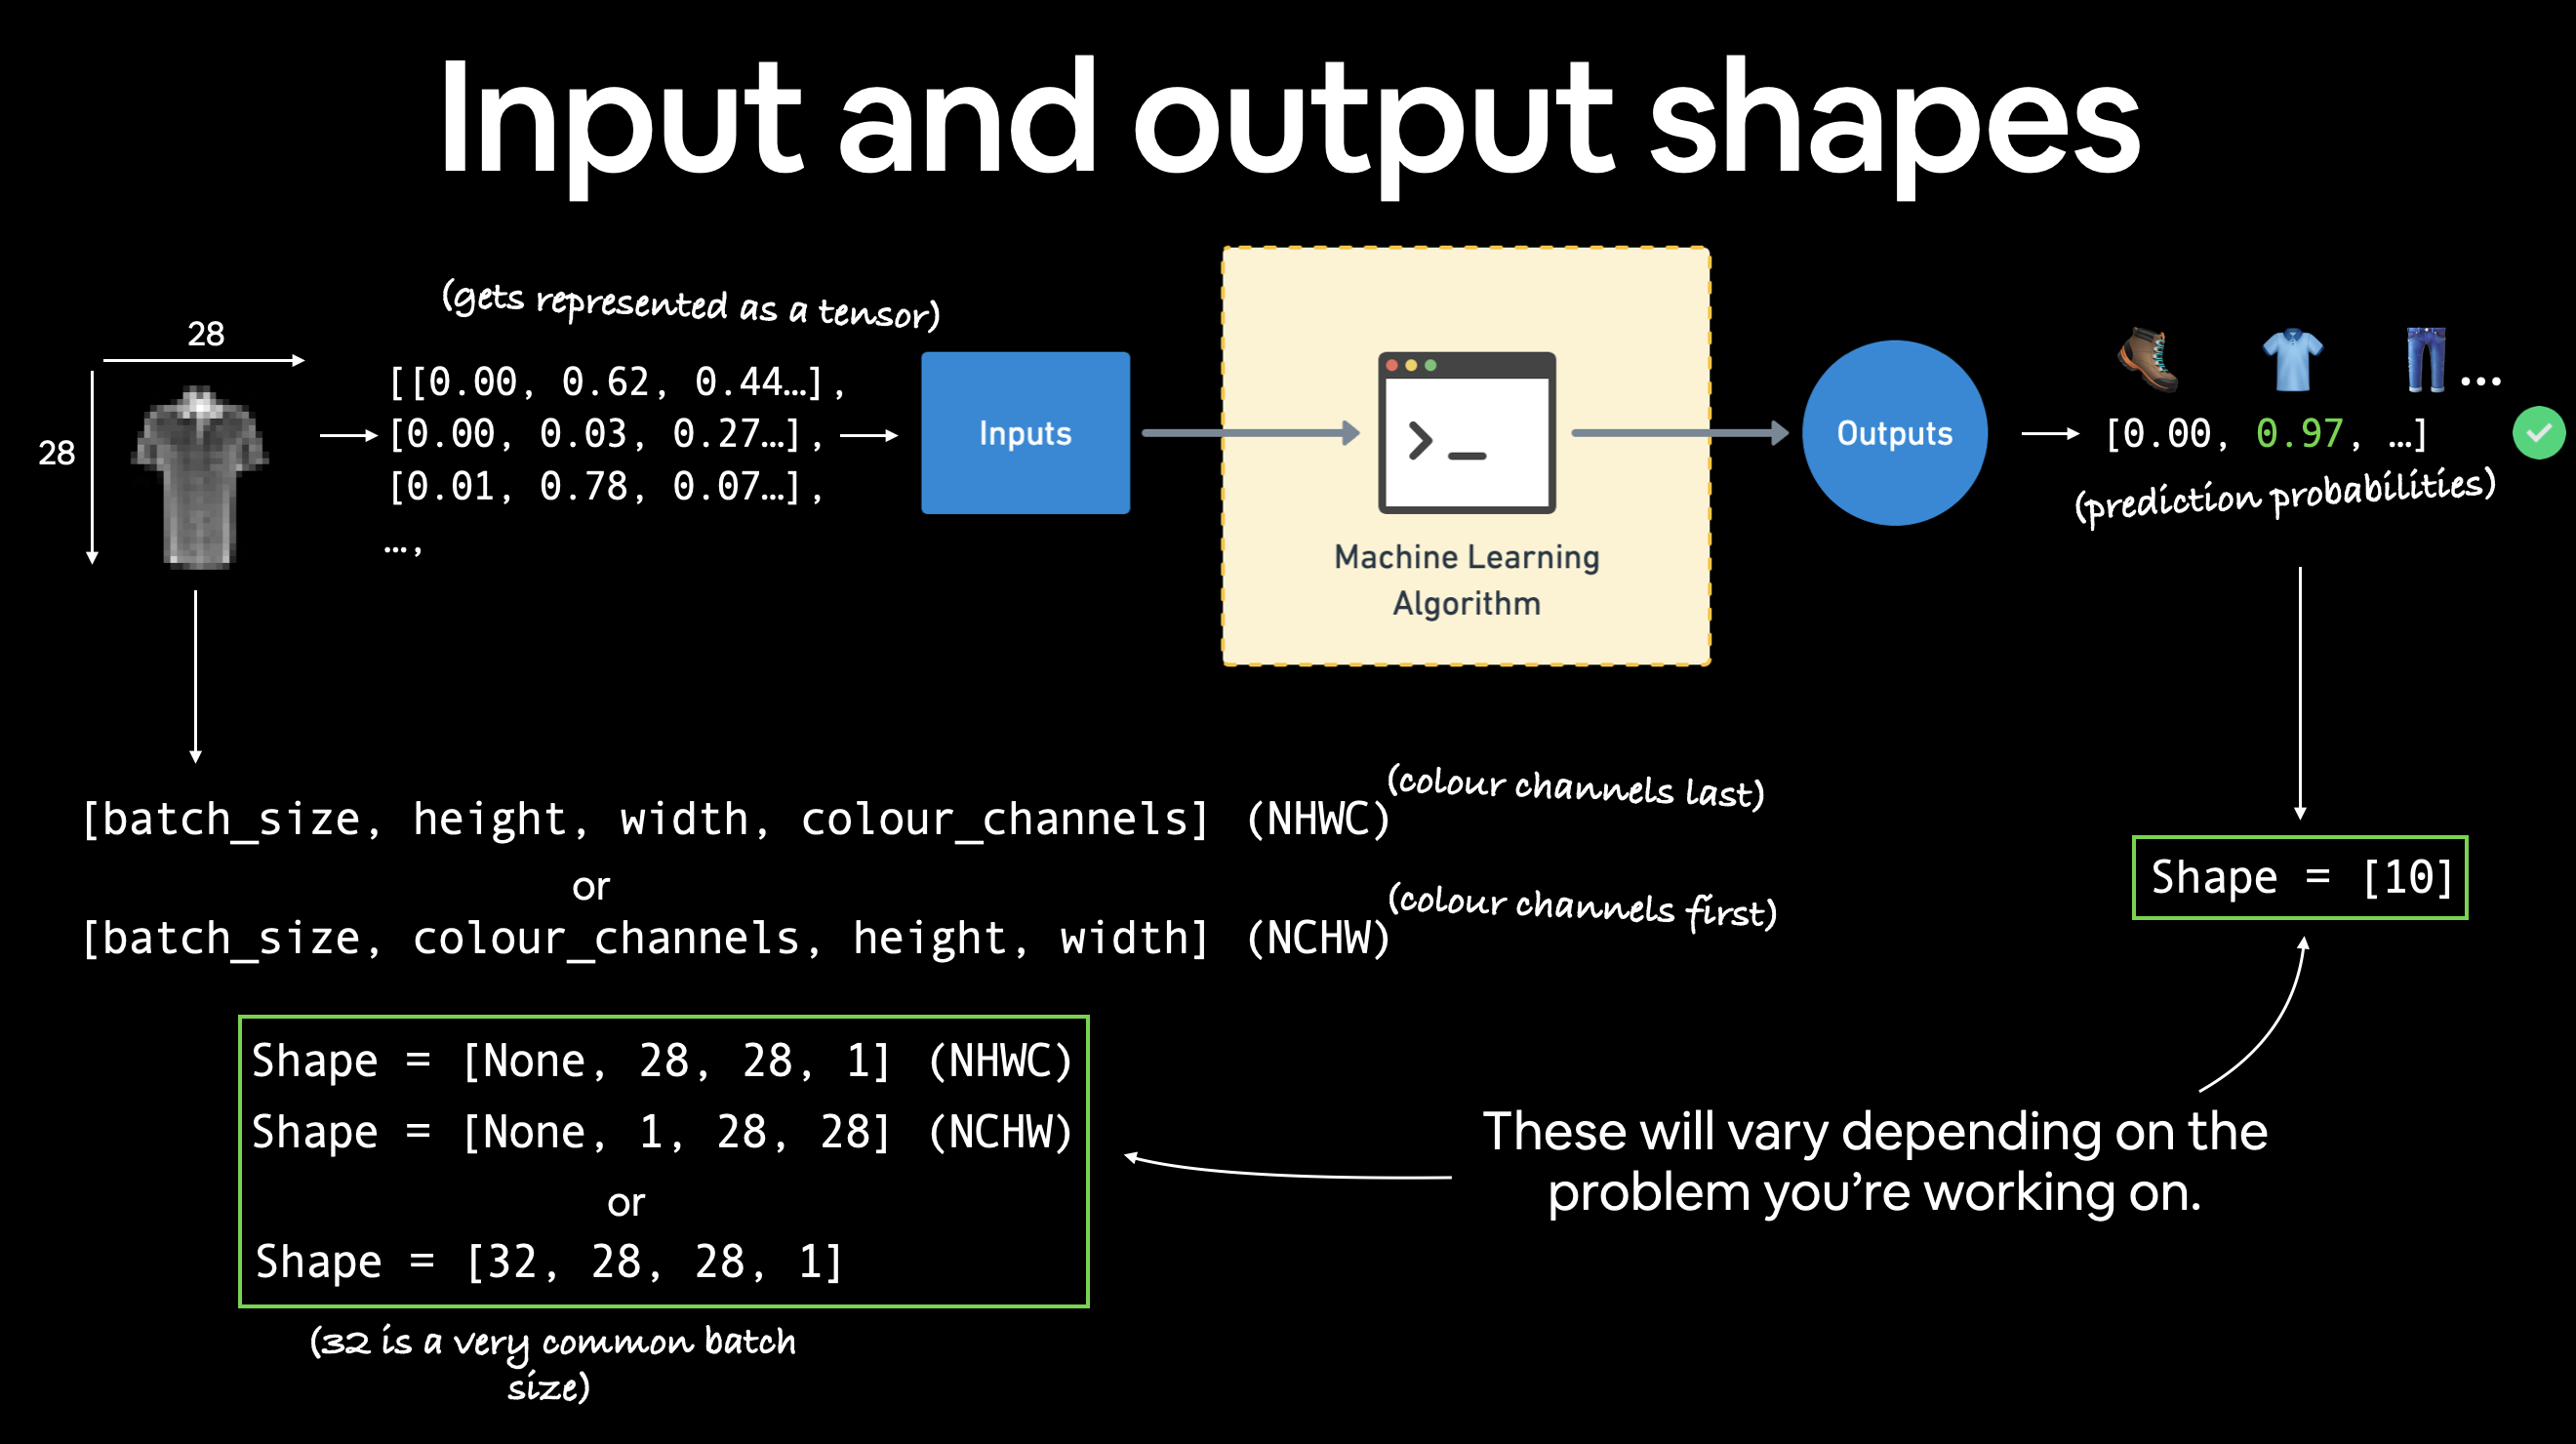

In [ ]:
from PIL import Image

duong_dan = '03-computer-vision-input-and-output-shapes.png'
img = Image.open(duong_dan)
img

*Các bài toán khác nhau sẽ có những dạng đầu vào khác nhau. Nhưng vẫn dữ liệu cách thức từ mã hóa dữ liệu thành những con số, xây dựng một mô hinh để tìm các mẫu trong những con số đó, chuyền mẫu đó thành những thứ có nghĩa*

Nếu `color_channels = 3` tức hình cảu ta có tới 3 giá trị pixel của đỏ, xanh lá, xanh nước biển (hay nói cách khác là mã [RGB](https://en.wikipedia.org/wiki/RGB_color_model)).

Tensor sẽ được biểu diễn đối với một dữ liệu hình ảnh theo quy tắc `CHW` (Color Channels, Height, Width) và hình ảnh cũng nên được biểu diễn bằng việc `CHW` hay `HWC`

> Tuy nhiên ta cũng sẽ thấy `NCHW` và `NHWC` với `N` biểu diễn cho số lượng ảnh. Láy ví dụ ta chọn `batch_size=32` thì tensor sẽ có shape [32, 1, 28, 28]

PyTorch sẽ biểu diễn tensor ảnh theo quy tắc `NCHW` (color_channels đầu tiên) tuy nhiên tốt hơn hết là nên thep quy tắc `NHWC`. Đối với dữ liệu mẫu nhỏ thì không thấy rõ sự khác biệt nhưng khi làm với mẫu lớn cũng như mạng CNN ta sẽ thấy rõ hơn

Xem thêm: https://pytorch.org/blog/tensor-memory-format-matters/#pytorch-best-practice (format nào tensor trong xử lý ảnh là tốt)

In [ ]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

In [ ]:
# See classes
class_names = train_data.classes
class_names

Vậy ta đã có 60000 mẫu huấn luyện mô hình và 10000 mẫu để testing và cũng đó có 10 nhãn khác nhau đây chính là một bài toán **multi-class classification**

### **Trực quan hóa dữ liệu**

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label);

Ta cũng có thể chuyển mã màu này về màu xám dùng `cmap` của `plt.imshow()`

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

Ta sẽ thực hiện việc xây dựng mô mô hình phân loại hình ảnh trong thị giác máy tính, bằng cách lấy các giá trị pixels của hình ảnh để tìm patterns của chúng khi xuất hiện một hình ảnh mới

> **Câu hỏi:** Những dữ liệu này là một dạng dữ liệu phi tuyến rời rạc

## **2. Chuẩn bị DataLoader**

Sau khi ta đã có dữ liệu để huấnuyện bước tiếp theo chính là chuẩn bị chúng vào hàm `DataLoader` trong `torch.utils.data.DataLoader` hàm này giúp:
- Nạp dữ liệu vào mô hình cho việc huấn luyện và cho việc inference nó chuyển một bảng dữ liệu lớn thành những đoạn Python có thể tái sử dụng nhiều lần và có thể tách thành những số lượng nhỏ hơn (chunks)

- Số lượng tách nhỏ hơn đó được gọi là **batches** hoặc **mini-batches** và có thể được đặt trong `batch_size`. Làm việc này là để có lợi hơn về mặt tính toán, có thể các phép tính sẽ được tính toán nhanh hơn khi cho một lượng dữ liệu nhỏ giúp ích qua quan sát mô hình và có không gian để cải thiện. [32_batch là số lượng lý tưởng để bắt đầu](https://x.com/ylecun/status/989610208497360896?s=20&t=N96J_jotN--PYuJk2WcjMw) Tuy nhiên ta cũng có thể thử nhiều batch khác nhau (32, 64, 128, 256, ... )



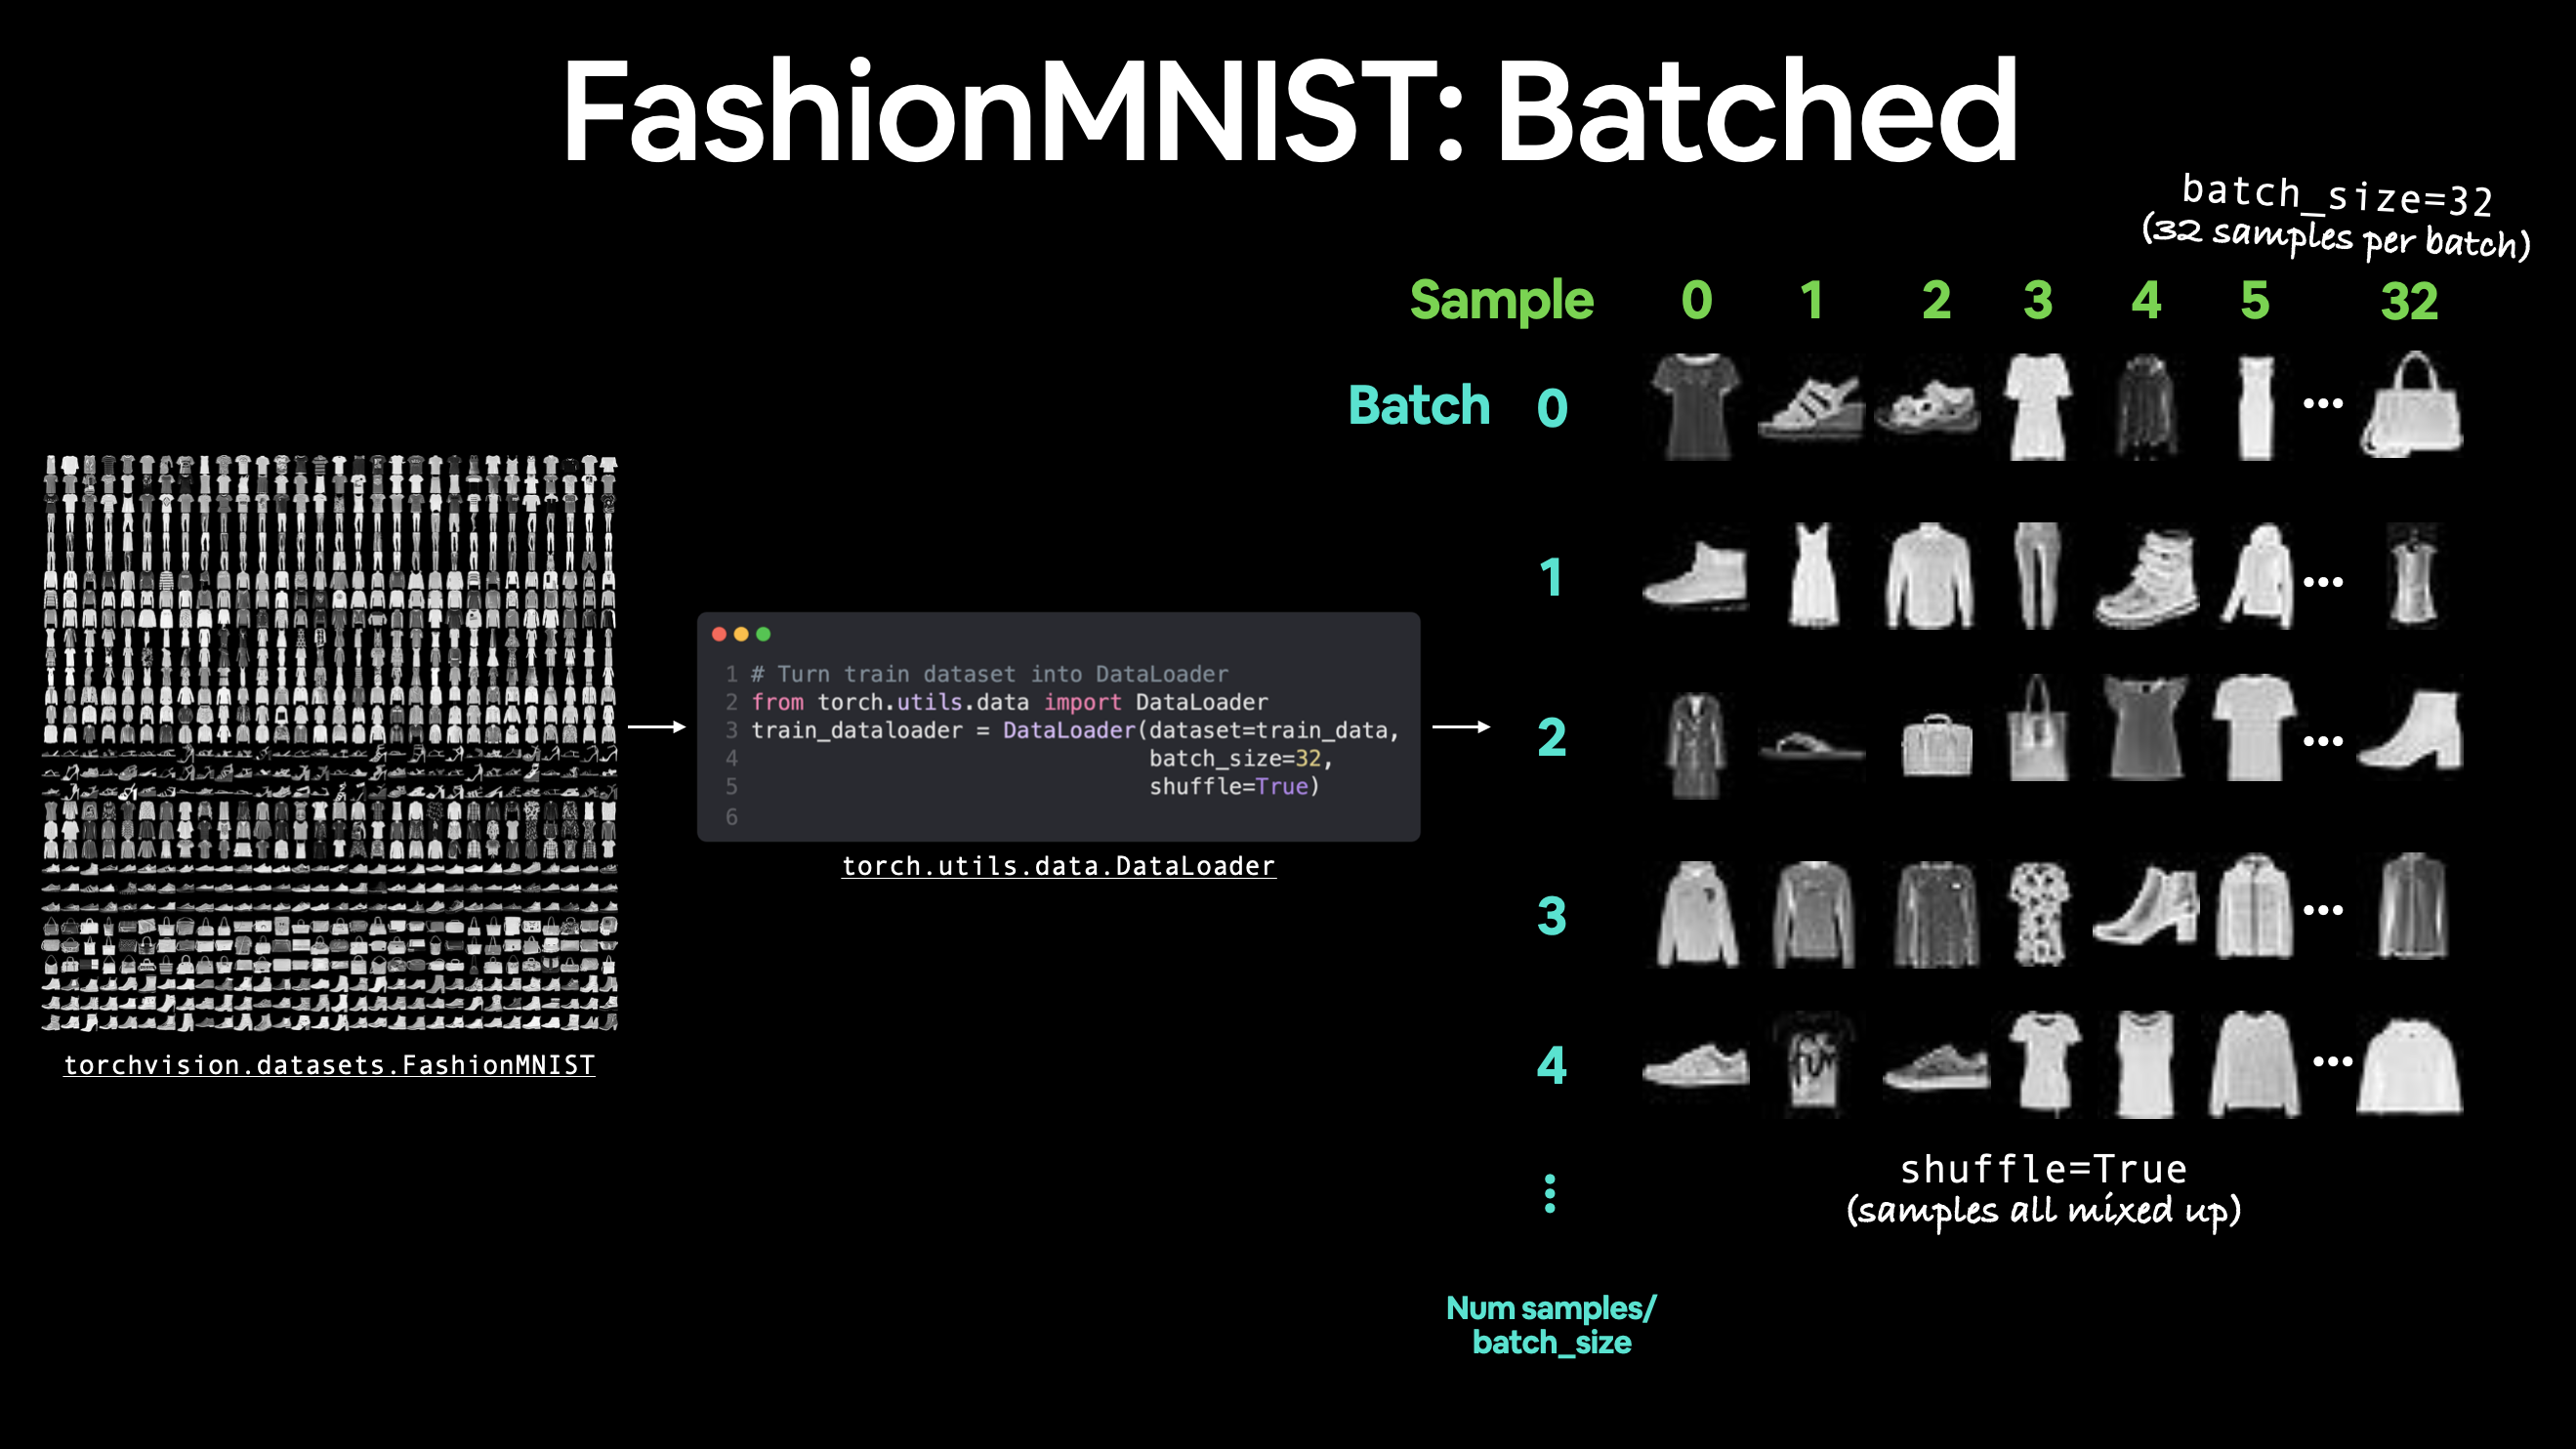

In [ ]:
from PIL import Image

duong_dan = '03-batching-fashionmnist.png'
img = Image.open(duong_dan)
img

Lây tổng cộng **32** mẫu thông qua những batch khác nhau

In [ ]:
# Tạo DataLoader cho tập training và test

from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

Ta sẽ không thấy dữ liệu bị thay đổi về kích htuwosc và thuộc tính

In [ ]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## **3. Model 0: Xây dựng mô hình ban đầu (baseline)**

Sau khi đã xây dựng DataLoader ta sẽ xây dựng **mô hình ban đầu** sử dựng `nn.Module` chính là mô hình đơn giản nhất mà ta có thể nghĩ tới. Là mô hình bắt đầu để ta có thể xây dựng và cải thiện chúng với những phép biến đổi hay kết hợp nhiều mô hình.

- **Mô hình baseline** sẽ có 2 lớp tuyến tính `nn.Linear()`. Do làm với dữ liệu hình ảnh nên ta sẽ sử dụng `nn.Flatten()` giúp chuyển các tham chiếu của tensor trở thành một vector đơn


In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
#print(x)
#print(output)

Hàm `nn.Flatten()` chuyển hình dạng `[color_channels, height, width]` thành `[color_channel, height * width]`. Ta làm điều này là bởi ta đã chuyển pixel của ảnh thành một **vector đặc trưng**. Và hàm `nn.Linear()` sẽ thực hiện tốt với dũ liệu đầu vào là một vector dặc trưng

In [ ]:
# Xấy dựng mô hình với nn.Flatten() là lớp đầu tiên

from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

Như vậy ta đã có mô hình đầu tiên (baseline) mô hình này sẽ bao gồm các tham số:
- `input_shape=784` chính là số lượng đặc trưng ta đặt vào mô hình, trường hợp này chính là pixel của hình ảnh (height * width)
- `hidden_units=10` số lượng nơ ron trong một lớp hidden trong trường hợp muốn giữ cho mô hình nhỏ ta sẽ đặt chúng là `10`
- `output_shape=len(class_names)` khi ta làm việc với phân loại nhiều nhãn ta sẽ cần một đầu ra của nơ ron ứng với từng class của bộ dữ liệu của ta

Bây giờ ta sẽ tạo nên chạy của mô hình trong CPU (ta sẽ chạy một đoạn test nhỏ `model_0` trong CPu)

In [ ]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_0.to("cpu") # keep model on CPU to begin with

### **Cài đặt loss, bộ tối ưu và metrics đánh giá**

Khi làm việc với việc bài toán phân loại ta sẽ sử dụng hàm `accuracy_fn()` tuy nhiên trong PyTorch ta cũng sẽ có những hàm metrics để đánh giá tương tự


In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### **Tạo hàm lưu thời gian cho mỗi lần chạy kiểm thử**

Tạo một hàm thời gian đảm bảo việc so sánh mô hình khi dược huấn luyện trên CPU khác nhau như thế nào với GPU. Ta sẽ huấn luyên trên CPU trước rồi với GPU. Hàm đếm thời gian được sử dụng trong `timeit.default_timer()`


In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### **Tạo training loop và huấn luyện mô hình trên tập batches của dữ liệu**

Ta sẽ sử dụng chung ý tưởng với các lần huấn luyện thông thường sau khi đã trải qua các bước như đặt thời gian, tìm hàm loss, bộ tối ưu cũng như mô hình và dữ liệu. Tuy nhiên hơi khác một chút:
- Dữ liệu trong một batches của ta sẽ được chia thành `train_dataloader` và `test_dataloader` với batch chính là `BATCH_SIZE` với `x` là đặc trưng còn `y` là nhãn mỗi batth của ta sẽ bao gồm 32 ảnh và nhãn khác nhau

- Các phép tính hàm tối ưu cũng như cập nhật sẽ dược tính trên mỗi **batch** qua một bảng dữ liệu lớn. Điều này khiến ta phải choa loss và accuracy của cho số lượng batches trong mỗi một bộ dataloader

Các nước diễn ra như sau:
1. Lặp qua mỗi epochs
2. Lặp qua batches training tính toán bước train cập nhật loss qua mỗi batch
3. Tương tự như training thì làm vậy với tập test
4. Xuất ra ngoài
5. Tính toán thời gian tất cả các bước




In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

## **4. Thực hiện dự đoán và lấy kết quả Model 0**

Ta đã xây dựng xong mô hình và huấn luyện nó. Bây giờ ta sẽ sử dụng mô hình đã huấn luyện với `DataLoader` hàm loss và accuracy nhằm dự đoán mô dữ liệu trong tập `DataLoader` và ta có thể đánh giá những dự đoán đó sử dụng hàm loss và accuracy

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

## **5. Kiểm thử các code và mô hình trên GPU**

> Tốc độ khi huấn luyện mô hình sẽ phụ thuộc vào phần cứng sử dụng. Nhiều tác vụ sẽ đồng nghĩa với việc training châm hơn và mô hình nhỏ hơn sẽ có thể gian training nhanh hơn các mô hình lớn cũng như dữ liệu lớn

Ta sẽ chuẩn bị phần cứng chạy code cho mô hình và dữ liệu sử dụng GPU. Nếu sử dụng Google Colab có thể vào `Runtime -> Change runtime type -> Hardware accelerator -> GPU` để bật GPU

In [ ]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

## **6. Model 1: Xây dựng mô hình tốt hơn với hàm phi tuyến**

Ta đã biết về sức mạnh của hàm phi tuyến. Nhắc lại một chút tuyến tính hay trái ngược với phi tuyến thì các tập dữ liệu sẽ biểu diễn thành một đường thẳng. Ta sẽ tạo lại một mô hình giống với mô hình trước những ta sẽ thêm hàm phi tuyến (`nn.ReLU()`) giữa các lớp tuyến tính




In [ ]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

Ta sẽ xem qua mô hình một chút:
- `input_shape=784` (bằng với số lượng đặc trưng trong dữ liệu ảnh của ta)
- `hidden_units=10` (bắt đầu với units nhỏ và giống với mô hình baseline)
- `output_shape=len(class_names)` (một unit đầu ra bằng với mỗi class).

> **Lưu ý:** Việc giữ lại toàn vẹn cấu trúc và chỉ thêm lớp phi tuyến là một tiêu chuẩn khi thực hiện việc chạy các thí nghiệm một cách từ từ. Thay đổi 1 thứ để xem xảy ra như thế nào

In [ ]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, # number of input features
    hidden_units=10,
    output_shape=len(class_names) # number of output classes desired
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device # check model device

### **Cài đặt loss, bộ tối ưu và metrics đánh giá**

Như thường lệ vẫn cài đặt hàm loss và bộ tối ưu cùng với metric đánh giá (có thể cài thêm nhiều metric nếu muốn)


In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### **Các chức năng cho vòng lặp training vá test**

Lần này ta sẽ viết các lần lặp training và testing này thành một hàm để có thể tái sử dụng nhiều lần. Và bởi vì ta sử dụng các phàn cứng thiết bị khác nhau ta phải chắc rằng `.to(device)` được gọi trên tensors `x` và `y` nhằm đưa chúng về cùng một môi trường chạy
- Cho training loop ta dùng hàm `train_step()` đặt mô hình và lấy dữ liệu từ `DataLoader` cùng hàm loss và bộ tối ưu
- Cho test loop ta dùng hàm `test_step()` đặt mô hình và lấy dữ liệu từ `DataLoader` cùng hàm loss và hàm đánh giá

> **Lưu ý:** Các hàm sau đây sẽ được gọi là xương sống ta có thể thay đổi tùy theo sở thích


In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

Sau khi đã xây dựng các hàm training và testing. Ta sẽ thưc hiện như vậy trong các vòng lặp khác cho mỗi epoch. Điều này tức là mỗi epoch sẽ qua các bước step training và testing

> **Lưu ý:** Ta có thể thay đổi các step trong training và testing. Điều mọi người thường làm sẽ hay set 5 hoặc 10 epochs hoặc trong trường hợp này là mỗi epoch

Ta cũng sẽ đặt thời gian khi chạy trên GPU

In [ ]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

> **Lưu ý:** Thời gian training trên CUDA vs CPU sẽ phụ thuộc vào số lượng trên cháy lượng CPU/GPU ta sử dụng

> Tuy nhiên một số trường hợp ta sử dụng GPU thay vì CPU nhưng thời gian vẫn chậm điều này là do dữ liệu và mô hình đều quá nhỏ nên lợi ích của việc sử dụng GPU vượt quá thời gian thực sự để thực hiện. Hoặc có một chướng ngại khi sao chép từ CPU sang GPU. Do đó vói dữ liệu và mô hình nhỏ CPU có thể là lựa chọn tối ưu. Nhưng đối với các bộ dữ liệu và mô hình lớn hơn, tốc độ tính toán của GPU thường vượt xa chi phí để chuyển dữ liệu đến đó. Tuy nhiên, điều này phần lớn phụ thuộc vào phần cứng mà ta đang sử dụng. Với thực hành, ta sẽ quen với nơi tốt nhất để huấn luyện các mô hình của mình.

In [ ]:
# Thực hiện đánh giá trên `model_1` sử dụng eval_model()

torch.manual_seed(42)

# Note: This will error due to `eval_model()` not using device agnostic code
model_1_results = eval_model(model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn)
model_1_results

Tuy nhiên với lỗi:

> `RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)`

Điều này cho thấy ta đặt dữ liệu và mô hình trên một mô trường chạy khác với hàm đánh giá đang dạy. Ta sẽ thử đặt `device` vào hàm `eval_model()` của ta

In [ ]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

In [ ]:
# Check baseline results
model_0_results

Xem như khi mô hình thêm hàm phi tuyến có vè đạt hiệu suất tệ hơn mô hình baseline. Điều này nói lên rằng đôi khi thứ ta nghĩ thường không hoạt động. Và với trường hợp này xem như mô hình đang có khả năng **overfitting** trên tập training

Overftting là khi mô hình học quá tốt với dữ liệu training nhưng những pattern vừa học được không tốt với tập testing. Có hai cách để sửa overfitting:
1. Sử dụng mô hình nhỏ hơn hoặc mô hình khác (một số mô hình fit với dữ liệu hơn số lượng còn lại)
2. Sử dụng dữ liệu lớn hơn (nhiều dữ liệu, nhiều cơ hội để mô hình có thể học những patterns tổng quát).

Ta có thể tìm kiếm các cách để ngăn chặn overefitting. Trong trường hợp này ta sẽ thử sử dụng mô hình khác (1)

## **7. Model 2: Xây dựng mô hình Convolutional Neural Network (CNN)**

Đến với bước này ta sẽ thực hiện việc xây dựng một mô hình nơ ron tích chập [CNN](https://en.wikipedia.org/wiki/Convolutional_neural_network) mô hình CNN ta sử dụng được biết với tên TinyVGG từ [web](https://poloclub.github.io/cnn-explainer/).

Cáu trúc của mô hình CNN:
```
Lớp đầu vào -> [Lớp Convolutional -> Lớp kích hoạt -> Lớp pooling] -> Lớp đầu ra
```

Đối với lớp `[Lớp Convolutional -> Lớp kích hoạt -> Lớp pooling]` có thể sử dụng nhiều lần

Ngoài mô hình CNN ta cũng có nhiều mô hình khác ứng với mỗi bài toán khác nhau

- Với dữ liệu **có cấu trúc** có thể sử dụng các mô hình như *Gradient boosted, XGBoost, Random Forest*
- Với dữ liệu **phi cấu trúc** có thể sử dụng các mô hình như *CNN, Transformers*

Ngoài ra ta còn rất nhiều các mô hình khác và để có thể tạo được mô hình CNN ta có thể sử dụng `nn.Conv2d()` và `nn.MaxPool2d()` từ `torch.nn`

In [ ]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

### **Bước `nn.Conv2d()`**

Lớp `nn.Conv2d()` được biết đến với lớp convolutional

> 2d trong `Conv2d` thể hiện cho số chiều của dữ liệu, như ta đã biết hình ảnh của chúng ta có 2 chiều (cao và rộng). Với mỗi chiều color_channel lại có thểm một chiều cao và rộng. Với số chiều khác ta cũng có thể thay thế chăng hạn như (1 chiều cho văn bản hay 3 chiều cho thực thể `nn.Conv1d()` hay `nn.Conv3d()`)


Để kiểm tra đầu ra ta sẽ tạo một dữ liệu mẫu kiểm tra trong CNN

In [ ]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

Tạo hàm `nn.Conv2d()` với tham số
- `in_channels (int)` - Số lượng channels trong ảnh đầu vào
- `out_channels (int)` - Số lượng channels cho đẩu ra của convolution
- `kernel_size (int hay tuple)` - Kích thước của hàm convolving
- `stride (int hoặc tuple tùy lựa chọn)` - Các bước convolving lớp như thế nào qua từng lần (Mặc định là 1)
- `padding (int, tuple, str)` - Padding thêm cho tất cả 4 chiều của đầu vào

In [ ]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here

# Pass the data through the convolutional layer
conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input)

Nếu ta đặt mô hình ảnh vào hàm này ta sẽ sinh ra lỗi không khớp với shape

> Do hàm `nn.Conv2d()` chỉ nhận các dữ liệu 4 chiều tương đương hình ảnh có dạng một tensor `(N, C, H, W)` hoặc `[batch_size, color_channels, height, width]`. Hình ảnh `test_image` chỉ có dạng `[color_channels, height, width]` hoặc `[3, 64, 64]`.

Ta có thể sửa lỗi bằng cách `test_image.unsqueeze(dim=0)` để thêm một chiều cho `N`

In [ ]:
# Add extra dimension to test image
test_image.unsqueeze(dim=0).shape

In [ ]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

In [ ]:
torch.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

Nếu ta thay đổi `conv_layer` ta sẽ có một shape change mới, Bây giờ hình của ta sẽ có shape `[1, 10, 30, 30]` (sẽ thay đổi nếu sử dụng dữ liệu khác) hay `[batch_size=1, color_channels=10, height=30, width=30]`. Điều này có nghĩa hàm `nn.Conv2d()`đang nén các thông tin được lưu trữ trong hình ảnh. Bằng cách thực hiện các phép toán đầu vào dựa trên các tham số của nó, mục tiêu là làm tương đồng với tất cả các nơ ron xây dựng

Dữ liệu đi vào các hàm và thực hiện cập nhật các tham số nội bộ (patterns) giúp giảm hàm loss nhờ sự xuất hiện của bộ tối ưu.

Sự khác biệt duy nhất chính là làm cách nào để các hàm khác nhau có thể tính toán tham số cập nhật hoặc phéo tính nào được sử dụng trong hàm `foward()`. Ta sẽ tìm hiểu nó trong hàm `conv_layer_2.state_dict()`. Ta sẽ tìm weight và bias tương đòng với cái ta thấy

In [ ]:
# Check out the conv_layer_2 internal  (Kiểm tra tham số nội bộ của conv_layer_2)
print(conv_layer_2.state_dict())

Có rất nhiều các con số ngẫu nhiên của weight và bias tensor. Ta sẽ kiểm tra shape có giống với những gì ta đã cài đặt trong hàm `nn.Conv2d()` hay không

In [ ]:
# Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

> Về việc cài đặt các tham số trong hàm `nn.Conv2d()` ta có thể thực hiện các cách các giá trị tham số khác nhau để xem nó tác động thế nào đến hiệu suất của mô hình. Hoặc cách tốt hơn là tìm các ví dụ với bài toán tương đồng và copy nó

Các bước sau cũng sẽ tương tự: Thực hiện với các giá trị ngẫu nhiên rồi tìm cập nhật cho đến khi biểu diễn tốt nhất dữ liệu

### **Bước `nn.MaxPool2d()`**

Lớp `nn.MaxPool2d()` được biết đến với lớp max pooling cũng sẽ giống với bước `Convd2d()`


In [ ]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Có sự thay đổi giữa 2 shape với nhau. `kernel_size` của hàm `nn.MaxPool2d()` sẽ ảnh hưởng tới size của shape đầu ra cụ thể. Trong ví dụ shape giảm còn một nửa từ `62x62` xuống còn `31x31`

In [ ]:
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # see what happens when you change the kernel_size value

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

### **Cài đặt loss, bộ tối ưu và metrics đánh giá**


### **Training và testing qua các hàm train và test**


## **8. So sánh kết quả mô hình và thời gian huấn luyện**


### **Đánh đổi của hiệu suất tốc độ của mô hình**

## **9. Đánh già ngẫu nhiên dự đoán với mô hình tốt nhất**


## **10. Tạo ma trận nhầm lẫn (Confusion Matrix) để đánh giá dữ liệu dự đoán**


## **11. Lưu và nạp mô hình có hiệu suất tốt nhất**